In [11]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

# [Project -] 버스 정류장 승하차 인원 분석

---
## 프로젝트 목표
- 승차 또는 하차 시 해당 시간, 해당 정류장의 승객 수를 확인하기 위해 **버스 정류장 승하차 승객 수** 데이터와 **정류장 위치좌표** 데이터를 활용
- 탐색적 데이터 분석을 수행하기 위한 데이터 정제, 특성 엔지니어링, 시각화 방법 학습

---
## 프로젝트 목차
1. **데이터 읽기:** 버스 승하차 인원 정보 및 정류장 마스터 데이터를 불러오고 구조 확인
2. **데이터 정제 및 병합:** 두 데이터를 공통 ID를 기준으로 연결
3. **데이터 시각화:** 정류장 위치 좌표를 활용한 지도 시각화 및 승하차 패턴 분석

# [Project 0] 버스 정류장 승하차 인원 분석

---
## 프로젝트 목표
- 2020년과 2021년 2개년의 서울시 버스 노선별, 정류장별, 시간대별 대용량 데이터와 정류장 마스터 데이터를 결합하여 유의미한 교통 이용 패턴을 도출합니다.
- 시간대별로 세분화된 승하차 수치 데이터를 가공하여 분석 목적에 맞는 파생 변수를 생성하는 피처 엔지니어링(Feature Engineering) 역량을 강화합니다.
- **위도·경도 좌표 데이터를 활용해 승하차 밀집 지역을 공간 데이터로 시각화하고, 복잡한 수치 데이터를 직관적인 그래프로 전달하는 시각적 스토리텔링 기법을 학습합니다.**

---
## 프로젝트 목차
1. **데이터 읽기:** 2020년·2021년 버스 승하차 데이터 및 정류장 마스터 데이터 로드 및 구조 확인
2. **데이터 전처리:** 데이터 표기 포맷에 대응하는 시간대별 승하차 인원 동적 합산 및 연산 최적화를 위한 데이터 요약(Groupby)
3. **데이터 위치 병합:** 정류장 마스터에서 불필요한 속성을 제외한 위도·경도 좌표 데이터 선택 병합
4. **데이터 시각화:** 혼잡 시간대별 상위 정류장 분석 및 서울시 버스 24시간 전체 이용객 흐름 추이 시각화

[Cell 2: Python] 라이브러리 임포트 및 폰트 설정
한글 깨짐 현상을 방지하기 위해 기본 폰트를 설정합니다.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── Wilke 스타일: 흰 배경, 최소 격자, 고해상도 ────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

# ── 브랜드 색상 팔레트 (고정) ─────────────────────────────────
BRAND_COLORS = {
    'SK에너지':    '#E63946',
    'GS칼텍스':   '#457B9D',
    'S-OIL':      '#F4A261',
    '현대오일뱅크': '#2A9D8F',
    '알뜰주유소':  '#6D6875',
    '알뜰(ex)':   '#B5838D',
    'NH-OIL':     '#8338EC',
    '자가상표':    '#3A86FF',
    'NC오일':      '#FB5607',
    'SK가스':      '#FFBE0B',
}

print(" 환경 설정 완료")
print(f"   사용 폰트: {plt.rcParams['font.family']}")


[Cell 3: Python] 1. 2020년, 2021년 데이터 로드 및 결합 [수정됨]

In [13]:
import pandas as pd

# 1. 정류장 위치 데이터 불러오기
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
station_master_df = pd.read_csv(f"{DATA_PATH}/서울시_정류장마스터_정보.csv", encoding='cp949')

# 2. 2020년, 2021년 버스 승하차 정보 데이터 불러오기
# (파일이 위치한 폴더 경로에 맞게 실행해주세요)
df_2020 = pd.read_csv(f"{DATA_PATH}/2020년_버스노선별_정류장별_시간대별_승하차_인원_정보.csv", encoding='cp949')
df_2021 = pd.read_csv(f"{DATA_PATH}/2021년_버스노선별_정류장별_시간대별_승하차_인원_정보.csv", encoding='cp949')

# 3. 두 연도의 데이터를 위아래로 합치기 (통합)
passenger_df = pd.concat([df_2020, df_2021], ignore_index=True)

print("2020년, 2021년 데이터 결합 완료! 총 데이터 크기:", passenger_df.shape)
display(passenger_df.head(2))

2020년, 2021년 데이터 결합 완료! 총 데이터 크기: (938180, 55)


,사용년월,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,00시승차총승객수,00시하차총승객수,1시승차총승객수,1시하차총승객수,...,19시하차총승객수,20시승차총승객수,20시하차총승객수,21시승차총승객수,21시하차총승객수,22시승차총승객수,22시하차총승객수,23시승차총승객수,23시하차총승객수,등록일자
0,202001,100,100번(하계동~용산구청),100000002,01002,창경궁.서울대학교병원,1,0,0,0,...,34,82,16,44,37,49,27,20,15,20200203
1,202001,100,100번(하계동~용산구청),100000003,01003,명륜3가.성대입구,0,0,0,0,...,156,179,102,178,96,168,62,47,18,20200203


[Cell 4: Python] 2. 데이터 전처리 및 정류장별 압축 [수정됨]
데이터 용량이 크기 때문에 역명을 기준으로 데이터를 묶어주는 과정을 추가했습니다.

In [26]:
# 4셀: 시간대별 승하차 합산 및 (노선+정류장) 단위 압축

hourly_total_columns = []

for col in passenger_df.columns:
    if '승차' in col and '총승객수' in col:
        time_prefix = col.replace('승차총승객수', '').strip()
        off_col = f"{time_prefix}하차총승객수"

        if off_col in passenger_df.columns:
            new_col_name = f"{time_prefix}총승하차인원"
            passenger_df[new_col_name] = passenger_df[col] + passenger_df[off_col]
            hourly_total_columns.append(new_col_name)

# ★ 변경점: '역명'뿐만 아니라 '노선번호'도 포함하여 그룹화 (노선 정보 유지)
# 실제 데이터의 컬럼이 '노선명' 이라면 아래 '노선번호'를 수정하세요.
station_passenger_df = passenger_df.groupby(['노선번호', '역명'])[hourly_total_columns].sum().reset_index()

print("노선 및 시간대별 정류장 승하차 인원 합산 압축 완료!")
display(station_passenger_df.head(3))

노선 및 시간대별 정류장 승하차 인원 합산 압축 완료!


,노선번호,역명,00시총승하차인원,1시총승하차인원,2시총승하차인원,3시총승하차인원,4시총승하차인원,5시총승하차인원,6시총승하차인원,7시총승하차인원,...,14시총승하차인원,15시총승하차인원,16시총승하차인원,17시총승하차인원,18시총승하차인원,19시총승하차인원,20시총승하차인원,21시총승하차인원,22시총승하차인원,23시총승하차인원
0,0017,남이장군사당,606,1,0,0,0,1720,4605,10818,...,5369,5948,6248,7318,9765,9505,6042,5912,5732,3189
1,0017,산천동,476,3,0,0,0,5652,8917,22907,...,13785,15709,18027,18746,18146,16712,9752,9498,8221,4194
2,0017,산천동리버힐삼성아파트,651,1,0,0,0,2,725,2483,...,4535,5547,6860,7275,11790,12474,8032,7219,7474,3759


[Cell 5: Python] 3. 데이터 병합 (Merge)

In [27]:
# 5셀: 위치 데이터(위도, 경도) 선택 병합

station_coords = station_master_df[['정류장_명칭', '위도', '경도']].drop_duplicates(subset=['정류장_명칭'])

# 이름 기준으로 병합 (노선번호 컬럼은 자연스럽게 유지됩니다)
merged_df = pd.merge(
    station_passenger_df,
    station_coords,
    left_on='역명',
    right_on='정류장_명칭',
    how='inner'
)

merged_df = merged_df.drop(columns=['정류장_명칭'])

print("위도, 경도 데이터 병합 완료! 최종 데이터 크기:", merged_df.shape)
display(merged_df.head(3))

위도, 경도 데이터 병합 완료! 최종 데이터 크기: (20799, 28)


,노선번호,역명,00시총승하차인원,1시총승하차인원,2시총승하차인원,3시총승하차인원,4시총승하차인원,5시총승하차인원,6시총승하차인원,7시총승하차인원,...,16시총승하차인원,17시총승하차인원,18시총승하차인원,19시총승하차인원,20시총승하차인원,21시총승하차인원,22시총승하차인원,23시총승하차인원,위도,경도
0,0017,남이장군사당,606,1,0,0,0,1720,4605,10818,...,6248,7318,9765,9505,6042,5912,5732,3189,37.536659,126.957994
1,0017,산천동리버힐삼성아파트,651,1,0,0,0,2,725,2483,...,6860,7275,11790,12474,8032,7219,7474,3759,37.534500,126.951192
2,0017,삼성테마트,192,1,0,0,0,0,372,1938,...,2890,2785,3632,3523,2345,1954,1940,1154,37.533747,126.950385


[Cell 6: Python] 4. 분석 및 시각화

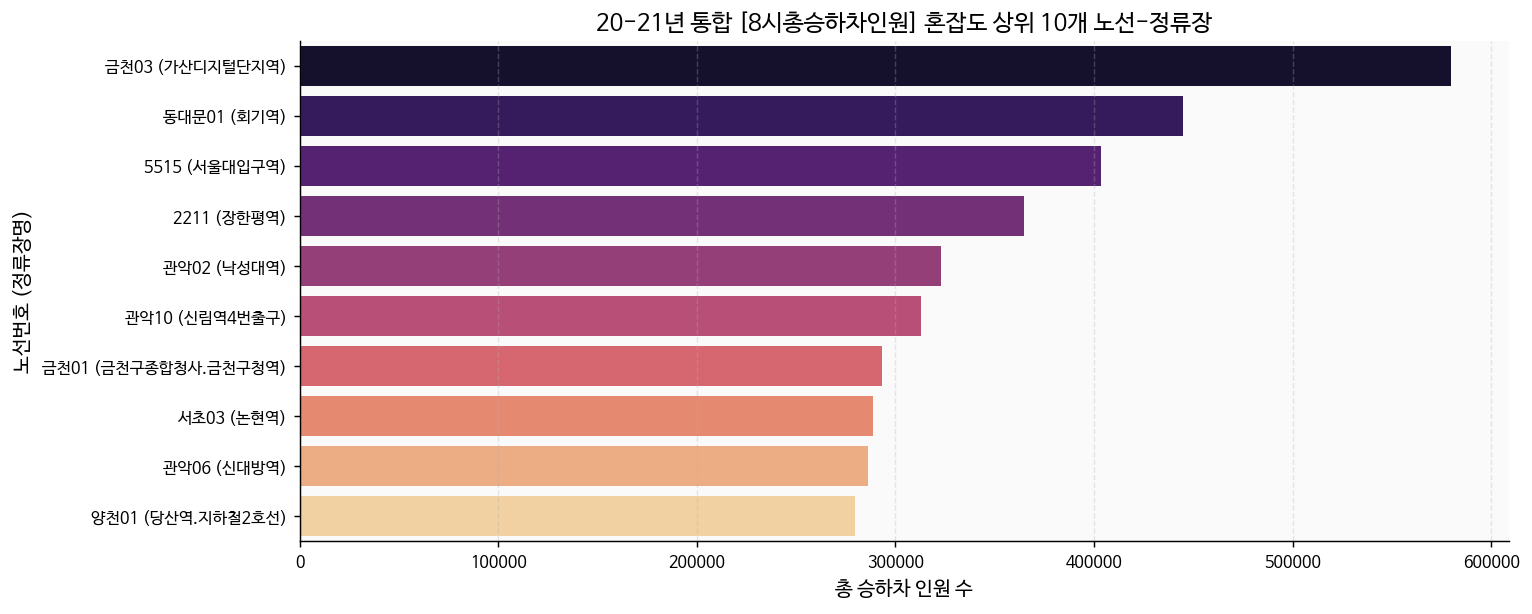

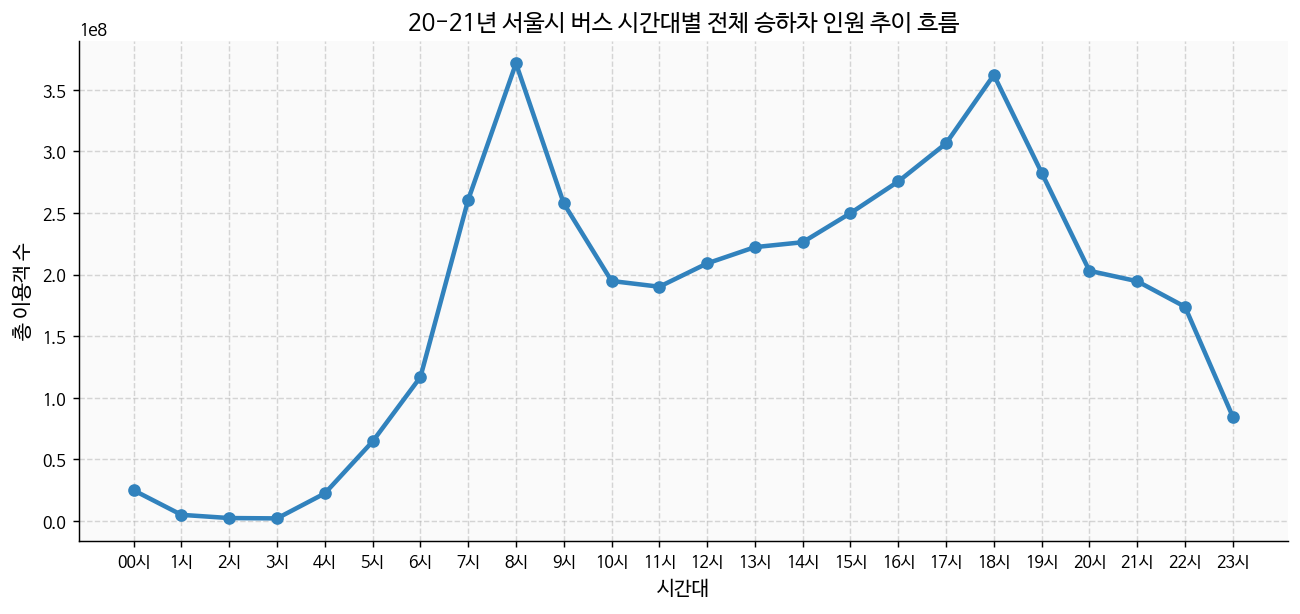

In [28]:
# 6셀: 노선 정보가 포함된 종합 시각화

import matplotlib.pyplot as plt
import seaborn as sns

target_time = "8시총승하차인원"

if target_time in merged_df.columns:
    # 상위 10개 추출 후 복사
    top_stations_time = merged_df.sort_values(by=target_time, ascending=False).head(10).copy()

    # ★ 변경점: Y축에 노선번호와 역명을 함께 표시하기 위해 새로운 컬럼 생성
    top_stations_time['노선_정류장'] = top_stations_time['노선번호'].astype(str) + " (" + top_stations_time['역명'] + ")"

    plt.figure(figsize=(12, 5))
    sns.barplot(x=target_time, y='노선_정류장', data=top_stations_time, palette='magma')
    plt.title(f'20-21년 통합 [{target_time}] 혼잡도 상위 10개 노선-정류장')
    plt.xlabel('총 승하차 인원 수')
    plt.ylabel('노선번호 (정류장명)')
    plt.show()

# 24시간 추이 선 그래프는 전체 통합 흐름이므로 이전 셀과 동일하게 유지합니다.
hourly_cols = [col for col in merged_df.columns if '총승하차인원' in col]
def get_hour_num(col_name):
    return int(col_name.split('시')[0])

try:
    hourly_cols = sorted(hourly_cols, key=get_hour_num)
    total_hourly_flow = merged_df[hourly_cols].sum()
    x_labels = [col.split('총')[0] for col in hourly_cols]

    plt.figure(figsize=(12, 5))
    plt.plot(x_labels, total_hourly_flow, marker='o', color='#3182bd', linewidth=2.5)
    plt.title('20-21년 서울시 버스 시간대별 전체 승하차 인원 추이 흐름')
    plt.xlabel('시간대')
    plt.ylabel('총 이용객 수')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
except Exception as e:
    print(f"선 그래프 생성 중 오류 발생: {e}")

[Cell 7: Python] 지도 시각화 (Folium) 코드 추가본

In [36]:
# 7셀: 노선별 필터링이 가능한 Folium 지도 시각화

import folium
import matplotlib.colors as mcolors

target_col = "8시총승하차인원"

if target_col in merged_df.columns:
    # 전체 데이터 중 혼잡도 상위 300개의 (노선-정류장) 데이터 추출
    map_df = merged_df.sort_values(by=target_col, ascending=False).head(300).reset_index(drop=True)
else:
    map_df = merged_df.head(300).reset_index(drop=True)

# 초기 지도 생성
center_lat, center_lon = 37.5665, 126.9780
map_osm = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# 상위 300개 안에 존재하는 고유 노선번호 목록 추출
unique_routes = map_df['노선번호'].unique()

# 노선별로 마커 색상을 다르게 주기 위한 색상표
colors = list(mcolors.TABLEAU_COLORS.values())

# ★ 변경점: 노선번호별로 그룹(Layer)을 만들어 지도에 추가
for idx, route in enumerate(unique_routes):
    # 각 노선 이름으로 레이어 그룹 생성
    route_group = folium.FeatureGroup(name=f"노선: {route}")

    # 해당 노선의 데이터만 필터링
    route_data = map_df[map_df['노선번호'] == route]
    marker_color = colors[idx % len(colors)] # 노선마다 다른 색상 할당

    for i in route_data.index:
        radius_size = (route_data[target_col][i] + 1) / 20000

        # 팝업에 노선번호와 정류장명, 인원수를 모두 표시
        popup_text = f"<b>노선:</b> {route}<br><b>정류장:</b> {route_data['역명'][i]}<br><b>승하차:</b> {int(route_data[target_col][i])}명"

        folium.CircleMarker(
            location=[route_data['위도'][i], route_data['경도'][i]],
            radius=radius_size,
            popup=folium.Popup(popup_text, max_width=300),
            color=marker_color,
            fill_color=marker_color,
            fill_opacity=0.6
        ).add_to(route_group) # 개별 마커를 맵 전체가 아닌 해당 노선 그룹에 추가

    # 완성된 노선 그룹을 지도에 추가
    route_group.add_to(map_osm)

# ★ 우측 상단에 노선을 켜고 끌 수 있는 체크박스(레이어 컨트롤) 추가
folium.LayerControl(collapsed=False).add_to(map_osm)

# 최종 지도 출력
map_osm

[Cell 8: Python] 지하철 데이터 로드 및 병합 확인 (데이터 점검용)

In [61]:
# 8셀: 퇴근 시간대(18시) 기준 지하철 데이터 정렬 및 병합 점검

import pandas as pd
import re

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset"
top_n = 100

def clean_station_name(name):
    name = str(name).strip()
    name = re.sub(r'\([^)]*\)', '', name)
    name = re.sub(r'역$', '', name)
    return name.strip()

# 1. 자동 인코딩 감지 및 승하차 데이터 로드
subway_file_path = f"{DATA_PATH}/Seoul_subway_data_20260606.csv"
subway_df = None
encodings_to_try = ['cp949', 'utf-8-sig', 'utf-8', 'euc-kr']

for enc in encodings_to_try:
    try:
        subway_df = pd.read_csv(subway_file_path, encoding=enc)
        break
    except UnicodeDecodeError:
        continue
    except FileNotFoundError:
        print(f"🚨 파일 없음 에러: 경로를 확인해주세요. ({subway_file_path})")
        break

if subway_df is not None:
    try:
        on_cols = [col for col in subway_df.columns if '승차인원' in col]
        off_cols = [col for col in subway_df.columns if '하차인원' in col]

        subway_df['일일총승차인원'] = subway_df[on_cols].sum(axis=1)
        subway_df['일일총하차인원'] = subway_df[off_cols].sum(axis=1)

        agg_dict = {col: 'sum' for col in on_cols + off_cols + ['일일총승차인원', '일일총하차인원']}
        subway_compressed = subway_df.groupby('지하철역').agg(agg_dict).reset_index()
        subway_compressed['지하철역'] = subway_compressed['지하철역'].apply(clean_station_name)
    except Exception as e:
        print(f"💡 전처리 오류: {e}")
        subway_compressed = pd.DataFrame(columns=['지하철역', '일일총승차인원', '일일총하차인원', '18시-19시 승차인원'])
else:
    subway_compressed = pd.DataFrame(columns=['지하철역', '일일총승차인원', '일일총하차인원', '18시-19시 승차인원'])

# 2. 위치 좌표 데이터 로드 및 정제
try:
    subway_location = pd.read_csv(f"{DATA_PATH}/subway_location_data.csv", encoding='utf-8')
    subway_location['지하철역'] = subway_location['지하철역'].apply(clean_station_name)
except Exception:
    try:
        subway_location = pd.read_csv(f"{DATA_PATH}/subway_location_data.csv", encoding='cp949')
        subway_location['지하철역'] = subway_location['지하철역'].apply(clean_station_name)
    except Exception as e:
        subway_location = pd.DataFrame(columns=['지하철역', 'x좌표', 'y좌표'])

# 3. 데이터 병합 및 퇴근 시간(18시) 기준 정렬
subway_map_df = pd.merge(
    subway_compressed,
    subway_location,
    on='지하철역',
    how='inner'
)

# 💡 핵심 변경점: 08시에서 18시로 타겟 시간 변경
target_time_col = '18시-19시 승차인원'

if target_time_col in subway_map_df.columns:
    subway_map_df = subway_map_df.sort_values(by=target_time_col, ascending=False).head(top_n).reset_index(drop=True)
else:
    subway_map_df = subway_map_df.sort_values(by='일일총승차인원', ascending=False).head(top_n).reset_index(drop=True)
    target_time_col = '일일총승차인원'

print(f"\n--- 📊 병합된 데이터 미리보기 ({target_time_col} 상위 5개역) ---")
display_cols = ['지하철역', target_time_col, '일일총승차인원', '일일총하차인원', 'x좌표', 'y좌표']
existing_cols = [col for col in display_cols if col in subway_map_df.columns]
display(subway_map_df[existing_cols].head())


--- 📊 병합된 데이터 미리보기 (18시-19시 승차인원 상위 5개역) ---


,지하철역,18시-19시 승차인원,일일총승차인원,일일총하차인원,x좌표,y좌표
0,가산디지털단지,56777286,222738813,233270403,37.482414,126.882240
1,선릉,48789980,254404494,256727212,37.507409,127.058026
2,강남,47541453,356919532,356253634,37.497057,127.028181
3,시청,43346457,194532850,190440008,37.565608,126.976945
4,여의도,42619923,192010508,195523941,37.522813,126.923035


[Cell 9: Python]버스 & 지하철 통합 지도 시각화 분리

In [62]:
# 9셀: 퇴근 시간대(18시) 기준 버스 및 지하철 통합 시각화

import folium

# 1. 버스 데이터 준비 (18시 기준)
# 💡 핵심 변경점: 8시에서 18시로 타겟 시간 변경
bus_target_col = "18시총승하차인원"

if bus_target_col in merged_df.columns:
    bus_map_df = merged_df.sort_values(by=bus_target_col, ascending=False).head(top_n).reset_index(drop=True)
else:
    bus_map_df = merged_df.head(top_n).reset_index(drop=True)

# 2. 지도 초기 설정
center_lat, center_lon = 37.5665, 126.9780
map_integrated = folium.Map(location=[center_lat, center_lon], zoom_start=11)

bus_group = folium.FeatureGroup(name=f"🚌 버스 정류장 (Top {top_n})")
subway_group = folium.FeatureGroup(name=f"🚇 지하철역 (Top {top_n})")

# 3. 버스 마커 그리기 (파란색)
for i in bus_map_df.index:
    bus_radius = max(3.0, (bus_map_df[bus_target_col][i] / 10000))
    # 팝업 텍스트 18시로 변경
    popup_text = f"<b>[버스]</b> {bus_map_df['역명'][i]}<br><b>18시 승하차:</b> {int(bus_map_df[bus_target_col][i]):,}명"
    folium.CircleMarker(
        location=[bus_map_df['위도'][i], bus_map_df['경도'][i]],
        radius=bus_radius,
        popup=folium.Popup(popup_text, max_width=300),
        color='blue', fill_color='blue', fill_opacity=0.4
    ).add_to(bus_group)

# 4. 지하철 마커 그리기 (빨간색)
for i in subway_map_df.index:
    # 💡 수정된 최적의 크기 비율 800000 적용
    subway_radius = max(4.0, (subway_map_df[target_time_col][i] / 800000))

    lat = subway_map_df['x좌표'][i]
    lon = subway_map_df['y좌표'][i]

    try:
        # 팝업 텍스트 18시로 변경
        popup_text = f"""
        <b>[지하철] {subway_map_df['지하철역'][i]}</b><br>
        <b>18시 승차:</b> {int(subway_map_df[target_time_col][i]):,}명<br>
        <b>일일 총승차:</b> {int(subway_map_df['일일총승차인원'][i]):,}명<br>
        <b>일일 총하차:</b> {int(subway_map_df['일일총하차인원'][i]):,}명
        """
        folium.CircleMarker(
            location=[lat, lon],
            radius=subway_radius,
            popup=folium.Popup(popup_text, max_width=300),
            color='red', fill_color='red', fill_opacity=0.7
        ).add_to(subway_group)
    except KeyError as e:
        print(f"오류: {e}")
        pass

# 5. 지도에 레이어 추가
bus_group.add_to(map_integrated)
subway_group.add_to(map_integrated)
folium.LayerControl(collapsed=False).add_to(map_integrated)

map_integrated

---
---
---

In [64]:
# 8셀: 모든 시간대 데이터 통합 및 정제
import pandas as pd
import re

def clean_station_name(name):
    name = str(name).strip()
    name = re.sub(r'\([^)]*\)', '', name)
    name = re.sub(r'역$', '', name)
    return name.strip()

# 1. 지하철 데이터 (자동 인코딩 감지)
subway_file_path = f"{DATA_PATH}/Seoul_subway_data_20260606.csv"
encodings = ['cp949', 'utf-8-sig', 'utf-8', 'euc-kr']

for enc in encodings:
    try:
        subway_df = pd.read_csv(subway_file_path, encoding=enc)
        break
    except: continue

# 시간대별 승차/하차 컬럼 자동 분류
on_cols = [c for c in subway_df.columns if '승차인원' in c]
off_cols = [c for c in subway_df.columns if '하차인원' in c]

# 역명 정제
subway_df['지하철역'] = subway_df['지하철역'].apply(clean_station_name)

# 데이터 압축 (역별로 모든 시간대 합산)
subway_compressed = subway_df.groupby('지하철역')[on_cols + off_cols].sum().reset_index()

# 위치 데이터와 병합
subway_location = pd.read_csv(f"{DATA_PATH}/subway_location_data.csv", encoding='utf-8')
subway_location['지하철역'] = subway_location['지하철역'].apply(clean_station_name)

subway_map_df = pd.merge(subway_compressed, subway_location, on='지하철역', how='inner')
print(f"✅ 지하철 병합 완료: {len(subway_map_df)}개 역")

✅ 지하철 병합 완료: 578개 역


In [65]:
# 10셀: 버스-지하철 인접 지점 추출 및 파일 저장

import pandas as pd
import numpy as np
import folium

# 1. 좌표 데이터 표준화 (위도, 경도 이름 통일)
# 버스: 위도, 경도 / 지하철: x좌표(위도), y좌표(경도)
bus_temp = bus_map_df[['역명', '위도', '경도']].copy()
bus_temp.columns = ['name', 'lat', 'lon']
bus_temp['type'] = '버스'

sub_temp = subway_map_df[['지하철역', 'x좌표', 'y좌표']].copy()
sub_temp.columns = ['name', 'lat', 'lon']
sub_temp['type'] = '지하철'

# 2. 격자(Grid) 생성 (소수점 둘째 자리 기준) - 1km 단위로 1차 필터링
bus_temp['grid'] = bus_temp['lat'].round(2).astype(str) + '_' + bus_temp['lon'].round(2).astype(str)
sub_temp['grid'] = sub_temp['lat'].round(2).astype(str) + '_' + sub_temp['lon'].round(2).astype(str)

# 3. 같은 격자 내 데이터만 병합 후 거리 계산
merged_grid = pd.merge(bus_temp, sub_temp, on='grid', suffixes=('_bus', '_sub'))

# 유클리드 거리 계산 (간략화된 거리 측정: 0.005도는 약 500m 이내)
merged_grid['dist'] = np.sqrt((merged_grid['lat_bus'] - merged_grid['lat_sub'])**2 +
                              (merged_grid['lon_bus'] - merged_grid['lon_sub'])**2)

# 거리 0.005 이하(약 500m)인 데이터만 추출
transfer_points = merged_grid[merged_grid['dist'] < 0.005].copy()

# 4. 파일 저장
save_path = f"{DATA_PATH}/transfer_points.csv"
transfer_points.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"✅ 인접 지점 {len(transfer_points)}개를 추출하여 '{save_path}'에 저장했습니다.")

# 5. 시각화 (인접 지점 지도 표시)
map_transfer = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

for i, row in transfer_points.iterrows():
    # 버스 위치 표시
    folium.CircleMarker(
        [row['lat_bus'], row['lon_bus']], radius=3, color='blue', popup=f"버스: {row['name_bus']}"
    ).add_to(map_transfer)
    # 지하철 위치 표시
    folium.CircleMarker(
        [row['lat_sub'], row['lon_sub']], radius=5, color='red', popup=f"지하철: {row['name_sub']}"
    ).add_to(map_transfer)

map_transfer

✅ 인접 지점 84개를 추출하여 '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/transfer_points.csv'에 저장했습니다.


In [67]:
# 12셀: 20시 이후 시간대별 환승 거점(Top 100 겹침) 분석

# 시간대별 매핑 (버스 컬럼명, 지하철 컬럼명)
time_map = {
    '20시': ('20시총승하차인원', '20시-21시 승차인원'),
    '21시': ('21시총승하차인원', '21시-22시 승차인원'),
    '22시': ('22시총승하차인원', '22시-23시 승차인원'),
    '23시': ('23시총승하차인원', '23시-24시 승차인원')
}

print("--- 🌙 20시 이후 시간대별 환승 거점 분석 시작 ---")

for hour, (bus_col, sub_col) in time_map.items():
    # 1. 컬럼 존재 여부 확인
    if bus_col not in merged_df.columns or sub_col not in subway_map_df.columns:
        print(f"⚠️ {hour} 데이터 컬럼 누락으로 건너뜁니다.")
        continue

    # 2. 해당 시간대 Top 100 추출
    bus_top = merged_df.sort_values(by=bus_col, ascending=False).head(100).copy()
    bus_top = bus_top[['역명', '위도', '경도']].rename(columns={'역명':'name', '위도':'lat', '경도':'lon'})

    sub_top = subway_map_df.sort_values(by=sub_col, ascending=False).head(100).copy()
    sub_top = sub_top[['지하철역', 'x좌표', 'y좌표']].rename(columns={'지하철역':'name', 'x좌표':'lat', 'y좌표':'lon'})

    # 3. 공간 조인 (격자 기반 최적화)
    bus_top['grid'] = bus_top['lat'].round(2).astype(str) + '_' + bus_top['lon'].round(2).astype(str)
    sub_top['grid'] = sub_top['lat'].round(2).astype(str) + '_' + sub_top['lon'].round(2).astype(str)

    merged = pd.merge(bus_top, sub_top, on='grid', suffixes=('_bus', '_sub'))
    merged['dist'] = np.sqrt((merged['lat_bus'] - merged['lat_sub'])**2 +
                             (merged['lon_bus'] - merged['lon_sub'])**2)

    # 500m 이내(0.005) 인접 지점
    overlaps = merged[merged['dist'] < 0.005].copy()

    print(f"\n[{hour} 시간대]")
    print(f"인접한 환승 거점 개수: {len(overlaps)}개")

    if len(overlaps) > 0:
        print(f"주요 거점(예시): {overlaps['name_bus'].head(3).tolist()}")
        # 파일 저장
        overlaps.to_csv(f"{DATA_PATH}/transfer_points_{hour}.csv", index=False, encoding='utf-8-sig')
    else:
        print("인접한 거점이 발견되지 않았습니다.")

print("\n--- 🏁 분석 완료: 각 시간대별 파일로 저장되었습니다. ---")

--- 🌙 20시 이후 시간대별 환승 거점 분석 시작 ---

[20시 시간대]
인접한 환승 거점 개수: 59개
주요 거점(예시): ['서울대입구역', '서울대입구역', '가산디지털단지역']

[21시 시간대]
인접한 환승 거점 개수: 58개
주요 거점(예시): ['서울대입구역', '서울대입구역', '가산디지털단지역']

[22시 시간대]
인접한 환승 거점 개수: 57개
주요 거점(예시): ['서울대입구역', '서울대입구역', '신도림역2번출구']

[23시 시간대]
인접한 환승 거점 개수: 59개
주요 거점(예시): ['서울대입구역', '서울대입구역', '낙성대역']

--- 🏁 분석 완료: 각 시간대별 파일로 저장되었습니다. ---


In [70]:
# 9셀 수정본: 시간대별 일관된 색상 테마 적용

import folium

# 1. 시간대별 색상 팔레트 정의 (버스: 밝은색, 지하철: 어두운색)
color_palette = {
    '20시': {'bus': '#87CEFA', 'subway': '#00008B'}, # Light Sky Blue, Dark Blue
    '21시': {'bus': '#90EE90', 'subway': '#006400'}, # Light Green, Dark Green
    '22시': {'bus': '#FFD700', 'subway': '#FF8C00'}, # Gold, Dark Orange
    '23시': {'bus': '#DDA0DD', 'subway': '#800080'}  # Plum, Purple
}

# 2. 지도 초기 설정
map_integrated = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

# 시간대 목록
time_slots = ['20시', '21시', '22시', '23시']

for hour in time_slots:
    # 해당 시간대용 레이어 그룹 생성
    group = folium.FeatureGroup(name=f"🔄 {hour} 통합 (버스/지하철)")

    # 3. 버스 데이터 (해당 시간대)
    bus_col = f"{hour}총승하차인원"
    if bus_col in merged_df.columns:
        bus_data = merged_df.sort_values(by=bus_col, ascending=False).head(100)

        for _, row in bus_data.iterrows():
            radius = max(3.0, (row[bus_col] / 200000))
            folium.CircleMarker(
                location=[row['위도'], row['경도']],
                radius=radius,
                popup=folium.Popup(f"<b>[버스] {hour}</b><br>{row['역명']}: {int(row[bus_col]):,}명", max_width=200),
                color=color_palette[hour]['bus'],
                fill_color=color_palette[hour]['bus'],
                fill_opacity=0.5
            ).add_to(group)

    # 4. 지하철 데이터 (해당 시간대)
    sub_col = f"{hour}-{int(hour.replace('시',''))+1}시 승차인원"
    # 데이터셋에 맞는 컬럼명이 아닐 경우 대비
    if sub_col not in subway_map_df.columns:
        sub_col = '일일총승차인원' # 데이터 부족시 총계 대체

    sub_data = subway_map_df.sort_values(by=sub_col, ascending=False).head(100)

    for _, row in sub_data.iterrows():
        radius = max(4.0, (row[sub_col] / 800000))
        folium.CircleMarker(
            location=[row['x좌표'], row['y좌표']],
            radius=radius,
            popup=folium.Popup(f"<b>[지하철] {hour}</b><br>{row['지하철역']}: {int(row[sub_col]):,}명", max_width=200),
            color=color_palette[hour]['subway'],
            fill_color=color_palette[hour]['subway'],
            fill_opacity=0.7
        ).add_to(group)

    group.add_to(map_integrated)

# 5. 레이어 컨트롤 추가
folium.LayerControl(collapsed=False).add_to(map_integrated)
map_integrated